# Recolección de Datos

## Cargar archivos mensuales desde el path local

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Carpeta local donde están los archivos Excel
RUTA_DATOS = Path(r"C:\TFM_Predictivo\2026")

archivos = [
    "SabanaEne2026.xlsx",
    "SabanaFeb2026.xlsx",
    "SabanaMar2026.xlsx",
    "SabanaAbril2026.xlsx",
    "SabanaMayo.xlsx",
    "SabanaJunio.xlsx"
]

dfs = []

for archivo in archivos:
    ruta = RUTA_DATOS / archivo

    df_tmp = pd.read_excel(
        ruta,
        sheet_name="Sabana",
        header=1,
        engine="openpyxl"
    )

    df_tmp["archivo_origen"] = archivo
    dfs.append(df_tmp)

    print(f"Cargado {archivo}: {len(df_tmp):,} registros")

# Consolidar los seis meses
dfMtto = pd.concat(
    dfs,
    ignore_index=True
)

# Eliminar columnas completamente vacías
dfMtto = dfMtto.dropna(
    axis=1,
    how="all"
)

print("\nArchivos cargados:", len(dfs))
print("Registros consolidados:", len(dfMtto))
print("Columnas:", len(dfMtto.columns))

c:\Users\cespa\anaconda3\envs\anaconda-ml-ai\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Cargado SabanaEne2026.xlsx: 19,522 registros


c:\Users\cespa\anaconda3\envs\anaconda-ml-ai\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Cargado SabanaFeb2026.xlsx: 19,219 registros


c:\Users\cespa\anaconda3\envs\anaconda-ml-ai\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


...

Cargado SabanaAbril2026.xlsx: 19,350 registros


c:\Users\cespa\anaconda3\envs\anaconda-ml-ai\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Cargado SabanaMayo.xlsx: 19,691 registros


c:\Users\cespa\anaconda3\envs\anaconda-ml-ai\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Cargado SabanaJunio.xlsx: 18,284 registros

Archivos cargados: 6
Registros consolidados: 116718
Columnas: 53


## Enmascaramiento de datos (Data Masking)  con tablas de equivalencia

In [2]:
# Cargar tablas de equivalencia desde archivo local
ruta_alias = RUTA_DATOS / "AliasTable.xlsx"

dffalla = pd.read_excel(ruta_alias, sheet_name="Falla")
dfcliente = pd.read_excel(ruta_alias, sheet_name="Cliente")
dfreque = pd.read_excel(ruta_alias, sheet_name="Reque")

# Validar que las tablas de equivalencia no tengan llaves duplicadas
assert not dffalla['Tipo Falla'].duplicated().any(), \
    "Hay valores duplicados en la tabla Falla"

assert not dfcliente['Patio'].duplicated().any(), \
    "Hay valores duplicados en la tabla Cliente"

assert not dfreque['Requerimiento Soporte'].duplicated().any(), \
    "Hay valores duplicados en la tabla Reque"

# Aplicar equivalencias
dfMttoA = pd.merge(
    dfMtto,
    dffalla,
    how="left",
    on="Tipo Falla",
    validate="m:1"
)

dfMttoA = pd.merge(
    dfMttoA,
    dfcliente,
    how="left",
    on="Patio",
    validate="m:1"
)

dfMttoA = pd.merge(
    dfMttoA,
    dfreque,
    how="left",
    on="Requerimiento Soporte",
    validate="m:1"
)

# Quitar las columnas originales que se enmascararon
cols_originales = [
    'Tipo Falla',
    'Patio',
    'Requerimiento Soporte',
    'Equipo Bus'
]

dfMttoA.drop(
    columns=[
        c for c in cols_originales
        if c in dfMttoA.columns
    ],
    inplace=True
)

print(
    f"Dataset después del enmascaramiento: "
    f"{dfMttoA.shape[0]:,} registros"
)

Dataset después del enmascaramiento: 116,718 registros


## Estandarizar nombres de columnas (sin espacios ni caracteres especiales).

In [3]:
import re
import unicodedata

#función para estandatrizar nombres de columnas:

def standardize_column_names(df):

    def clean_name(name):

        name = str(name)
        name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
        name = name.lower()
        name = re.sub(r'[^a-z0-9]', '_', name)
        name = re.sub(r'_+', '_', name)
        name = name.strip('_')

        return name

    # diccionario con los nombre originales para estandarizar
    new_columns = {col: clean_name(col) for col in df.columns}

    # Renombrar
    df = df.rename(columns=new_columns)

    return df

dfMtto_std = standardize_column_names(dfMttoA)
dfMtto_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116718 entries, 0 to 116717
Data columns (total 55 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   ticket                                   116718 non-null  int64         
 1   tipo                                     116718 non-null  object        
 2   servicio                                 116718 non-null  object        
 3   cola                                     116718 non-null  object        
 4   fecha_creacion                           116718 non-null  datetime64[ns]
 5   mes_creacion                             116718 non-null  object        
 6   fecha_resuelto                           115238 non-null  datetime64[ns]
 7   fecha_cierre                             116454 non-null  datetime64[ns]
 8   nota_cierre                              116708 non-null  object        
 9   estado                    

## Filtrado de registros según la lógica de negocio

Para el modelo se conservan tres tipos de registros con funciones distintas. Las fallas **ATRIBUIBLES** definen el evento objetivo; los registros **NO FALLA** se mantienen como posibles señales tempranas o reportes intermitentes; y los **MTTO PREVENTIVO** se conservan como intervenciones históricas. Las demás clasificaciones se excluyen del conjunto de modelado porque no representan el fenómeno que se desea predecir.

In [4]:
# Clasificaciones que aportan al problema predictivo
clasificaciones_modelo = ['ATRIBUIBLE', 'NO FALLA', 'MTTO PREVENTIVO']
cola_excluir = 'CES::REPOSICION DE ALMACEN SATELITE BUSES'

# Reviso primero la distribución completa
print("Distribución de Clasifica Falla antes del filtro:")
display(dfMtto_std['clasifica_falla'].value_counts(dropna=False).to_frame('registros'))

dfMtto = dfMtto_std.loc[
    (dfMtto_std['clasifica_falla'].isin(clasificaciones_modelo)) &
    (dfMtto_std['cola'] != cola_excluir) &
    (dfMtto_std['id_movil'].notna())
].copy()

# Estandarizar el identificador antes de filtrar registros globales terminados en ALL
dfMtto['id_movil'] = dfMtto['id_movil'].astype(str).str.strip().str.upper()
dfMtto = dfMtto[~dfMtto['id_movil'].str.endswith('ALL', na=False)]

# Eliminar tickets duplicados si existieran entre archivos mensuales
n_duplicados = dfMtto['ticket'].duplicated().sum()
print(f"Tickets duplicados detectados: {n_duplicados}")
dfMtto = dfMtto.drop_duplicates(subset='ticket', keep='last').reset_index(drop=True)

# Dejo solo las columnas que aportan valor al análisis.
# 'flota' proviene de AliasTable y se conserva como referencia para el análisis
# por cliente; no se utiliza automáticamente como predictor.
columnas_modelo = [
    'ticket', 'fecha_creacion', 'servicio', 'cola', 'id_movil',
    'quien_gestiona_buses', 'cambio_parte', 'partes_buses',
    'clasifica_falla', 'falla', 'equipo', 'clientebd', 'reqsp'
]

if 'flota' in dfMtto.columns:
    columnas_modelo.append('flota')

dfMtto = dfMtto[columnas_modelo]

print(f"Dataset final para EDA y modelado: {dfMtto.shape[0]:,} registros")
print("\nRegistros conservados por función:")
display(dfMtto['clasifica_falla'].value_counts().to_frame('registros'))

Distribución de Clasifica Falla antes del filtro:


,registros
clasifica_falla,
ATRIBUIBLE,38992
NO FALLA,36888
NO ATRIBUIBLE,16539
MTTO PREVENTIVO,14736
NO CORRESPON REPORT,9040
NO CLASIFICA,459
NaN,64


Tickets duplicados detectados: 0
Dataset final para EDA y modelado: 90,576 registros

Registros conservados por función:


,registros
clasifica_falla,
ATRIBUIBLE,38952
NO FALLA,36888
MTTO PREVENTIVO,14736


# Análisis Exploratorio de Datos (EDA)

## Top 10 tipos de fallas más frecuentes

C:\Users\cespa\AppData\Local\Temp\ipykernel_30568\4178195773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top10_fallas.index, y=top10_fallas.values, palette="viridis")


<module 'matplotlib.pyplot' from 'c:\\Users\\cespa\\anaconda3\\envs\\anaconda-ml-ai\\Lib\\site-packages\\matplotlib\\pyplot.py'>

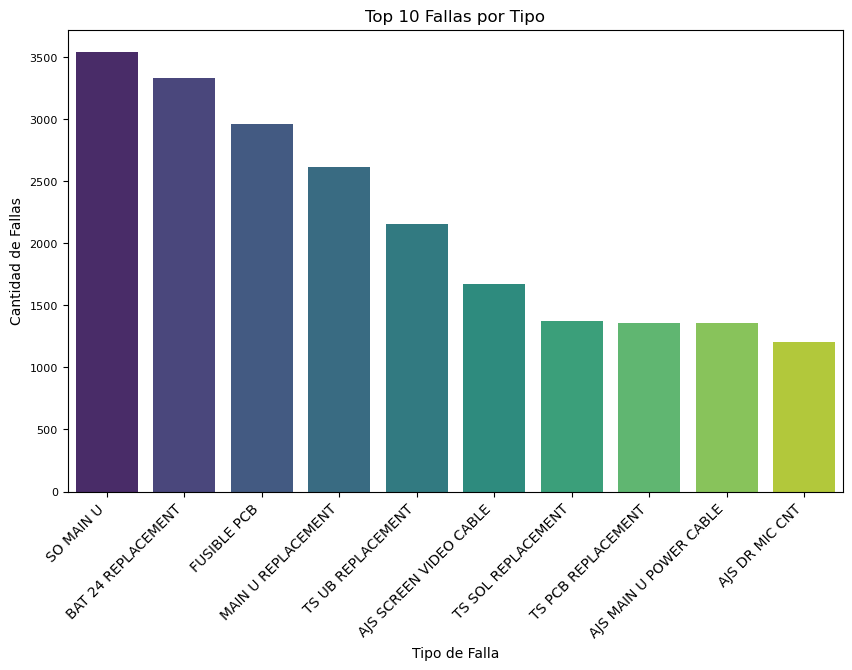

In [6]:
#Grafica Fallas por tipo top10:

import matplotlib.pyplot as plt
import seaborn as sns

#filtro solo Fallas reales
dfMttoF = dfMtto[dfMtto['clasifica_falla'] == 'ATRIBUIBLE']

top10_fallas = dfMttoF['falla'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_fallas.index, y=top10_fallas.values, palette="viridis")
plt.title('Top 10 Fallas por Tipo')
plt.xlabel('Tipo de Falla')
plt.ylabel('Cantidad de Fallas')

plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotar y ajustar la alineación
plt.yticks(fontsize=8)

plt

## Distribución porcentual de los diez tipos de falla más frecuentes

<module 'matplotlib.pyplot' from 'c:\\Users\\cespa\\anaconda3\\envs\\anaconda-ml-ai\\Lib\\site-packages\\matplotlib\\pyplot.py'>

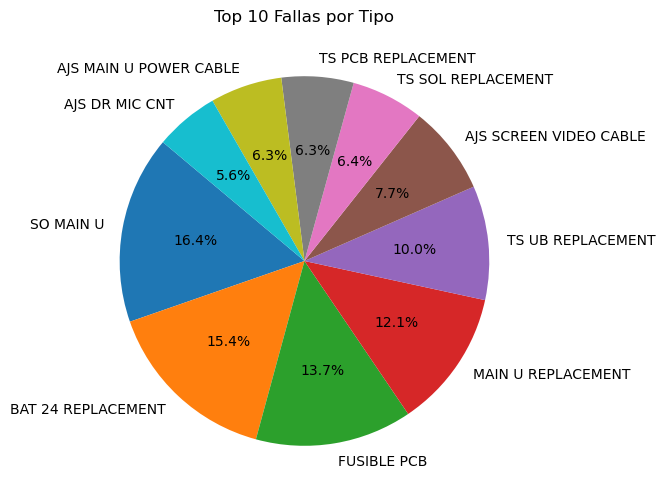

In [7]:
#Grafica Sectores distribución porcentual de fallas:

top10Fallas = dfMttoF['falla'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.pie(top10_fallas.values, labels=top10_fallas.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Fallas por Tipo')
plt

## Top 10 clientes con mayor volumen de fallas atribuibles

C:\Users\cespa\AppData\Local\Temp\ipykernel_30568\2240394533.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top10_Cliente.index, y=top10_Cliente.values, palette="viridis")


<module 'matplotlib.pyplot' from 'c:\\Users\\cespa\\anaconda3\\envs\\anaconda-ml-ai\\Lib\\site-packages\\matplotlib\\pyplot.py'>

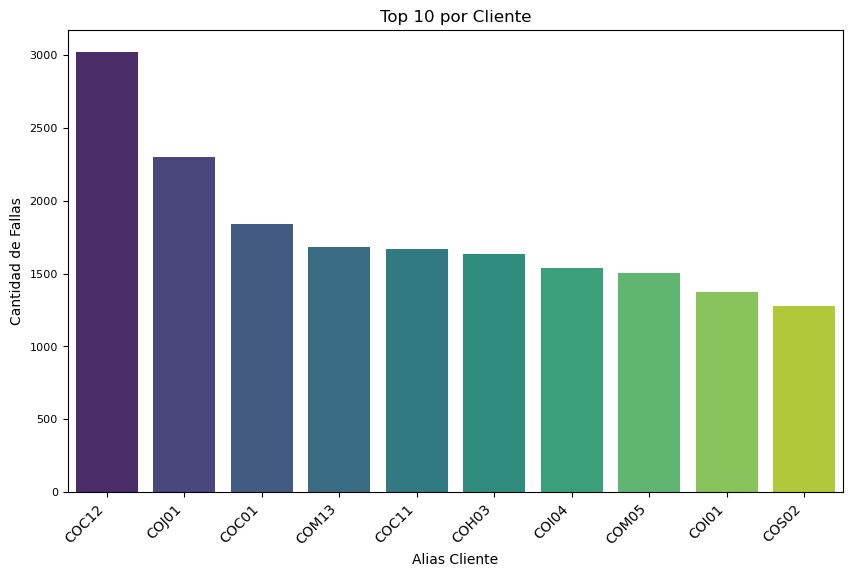

In [8]:
#Grafica por Cliente top10:

# Seleccionar Top 10
top10_Cliente = dfMttoF['clientebd'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_Cliente.index, y=top10_Cliente.values, palette="viridis")
plt.title('Top 10 por Cliente')
plt.xlabel('Alias Cliente')
plt.ylabel('Cantidad de Fallas')

plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotar y ajustar la alineación
plt.yticks(fontsize=8)

plt

## Evolución mensual de los principales tipos de requerimientos a lo largo del primer semestre de 2026

C:\Users\cespa\AppData\Local\Temp\ipykernel_30568\3284558228.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfMttoF['fecha_creacion'] = pd.to_datetime(dfMttoF['fecha_creacion'])
C:\Users\cespa\AppData\Local\Temp\ipykernel_30568\3284558228.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfMttoF['Mes'] = dfMttoF['fecha_creacion'].dt.to_period('M').astype(str)


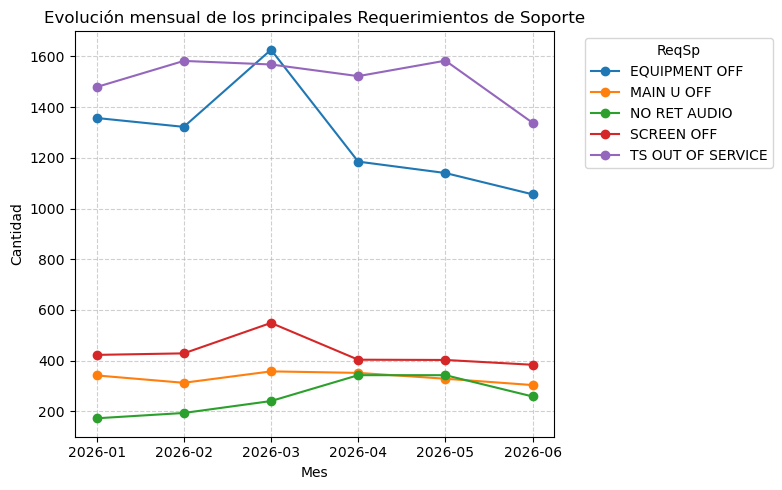

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que 'fecha_creacion' sea datetime
dfMttoF['fecha_creacion'] = pd.to_datetime(dfMttoF['fecha_creacion'])

# columna 'Mes' en formato YYYY-MM
dfMttoF['Mes'] = dfMttoF['fecha_creacion'].dt.to_period('M').astype(str)

df_agg = (
    dfMttoF.groupby(['Mes', 'reqsp'])
            .size()
            .reset_index(name='Cantidad')
)

# Seleccionar Top 5

top_req = (
    df_agg.groupby('reqsp')['Cantidad']
          .sum()
          .nlargest(5)
          .index
)

df_top = df_agg[df_agg['reqsp'].isin(top_req)]

# Pivotear para graficar
df_pivot = df_top.pivot(index='Mes', columns='reqsp', values='Cantidad').fillna(0)

# Grafica
plt.figure(figsize=(8, 5))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], marker='o', label=col)

plt.title('Evolución mensual de los principales Requerimientos de Soporte')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.legend(title='ReqSp', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Validación de `NO FALLA` y `MTTO PREVENTIVO` como antecedentes históricos

Antes de incorporarlos como variables del modelo se analiza si estos registros contienen información temporal respecto a una falla atribuible posterior. Para evitar sesgo por falta de seguimiento al final del semestre, en cada horizonte solo se incluyen registros con suficientes días de observación disponibles.


In [10]:
# Fecha máxima realmente observada en el conjunto
fecha_fin_eda = dfMtto['fecha_creacion'].max()

def siguiente_falla_atribuible(dff, clasificacion):
    base = (
        dff[dff['clasifica_falla'] == clasificacion]
        [['ticket', 'id_movil', 'fecha_creacion']]
        .sort_values('fecha_creacion')
        .copy()
    )

    fallas = (
        dff[dff['clasifica_falla'] == 'ATRIBUIBLE']
        [['id_movil', 'fecha_creacion']]
        .rename(columns={'fecha_creacion': 'fecha_prox_atribuible'})
        .sort_values('fecha_prox_atribuible')
    )

    return pd.merge_asof(
        base.sort_values('fecha_creacion'),
        fallas,
        by='id_movil',
        left_on='fecha_creacion',
        right_on='fecha_prox_atribuible',
        direction='forward',
        allow_exact_matches=False
    )


def resumen_horizontes(dff, clasificacion, horizontes=(7, 15, 30)):
    aux = siguiente_falla_atribuible(dff, clasificacion)
    aux['dias_hasta_atribuible'] = (
        aux['fecha_prox_atribuible'] - aux['fecha_creacion']
    ).dt.total_seconds() / 86400.0

    resultados = []
    for h in horizontes:
        elegibles = aux[
            aux['fecha_creacion'] <= fecha_fin_eda - pd.Timedelta(days=h)
        ].copy()

        ocurre = (
            elegibles['dias_hasta_atribuible'].notna() &
            (elegibles['dias_hasta_atribuible'] <= h)
        )

        resultados.append({
            'Clasificación inicial': clasificacion,
            'Horizonte_días': h,
            'Registros_elegibles': len(elegibles),
            'Falla_atribuible_posterior': int(ocurre.sum()),
            'Porcentaje': round(100 * ocurre.mean(), 2)
        })

    return pd.DataFrame(resultados)


resumen_no_falla = resumen_horizontes(dfMtto, 'NO FALLA')
resumen_preventivo = resumen_horizontes(dfMtto, 'MTTO PREVENTIVO')

resumen_antecedentes = pd.concat(
    [resumen_no_falla, resumen_preventivo],
    ignore_index=True
)

display(resumen_antecedentes)

# Analizo además si la recurrencia de NO FALLA aumenta la probabilidad de
# una falla atribuible en los siguientes 7 días.
tmp = dfMtto.sort_values(['id_movil', 'fecha_creacion']).copy()
tmp['no_falla_previos_30d'] = 0

for movil, idx in tmp.groupby('id_movil', sort=False).groups.items():
    g = tmp.loc[idx]
    fechas = g['fecha_creacion'].to_numpy(dtype='datetime64[ns]')
    clases = g['clasifica_falla'].to_numpy()
    fechas_no = fechas[clases == 'NO FALLA']

    conteo = np.zeros(len(g), dtype=int)
    for i, d in enumerate(fechas):
        if fechas_no.size:
            conteo[i] = (
                np.searchsorted(fechas_no, d, side='left') -
                np.searchsorted(
                    fechas_no,
                    d - np.timedelta64(30, 'D'),
                    side='left'
                )
            )
    tmp.loc[g.index, 'no_falla_previos_30d'] = conteo

nf = siguiente_falla_atribuible(tmp, 'NO FALLA')
nf = nf.merge(
    tmp[['ticket', 'no_falla_previos_30d']],
    on='ticket',
    how='left',
    validate='1:1'
)
nf['dias_hasta_atribuible'] = (
    nf['fecha_prox_atribuible'] - nf['fecha_creacion']
).dt.total_seconds() / 86400.0

nf = nf[
    nf['fecha_creacion'] <= fecha_fin_eda - pd.Timedelta(days=7)
].copy()
nf['falla_7d'] = (
    nf['dias_hasta_atribuible'].notna() &
    (nf['dias_hasta_atribuible'] <= 7)
).astype(int)

nf['recurrencia_no_falla'] = pd.cut(
    nf['no_falla_previos_30d'],
    bins=[-1, 0, 1, 2, np.inf],
    labels=['0', '1', '2', '3+']
)

tabla_recurrencia = (
    nf.groupby('recurrencia_no_falla', observed=False)
    .agg(
        registros=('ticket', 'size'),
        fallas_7d=('falla_7d', 'sum'),
        prob_falla_7d=('falla_7d', 'mean')
    )
    .reset_index()
)

tabla_recurrencia['prob_falla_7d'] = (
    100 * tabla_recurrencia['prob_falla_7d']
).round(2)

print("Relación entre NO FALLA previos en 30 días y falla atribuible posterior:")
display(tabla_recurrencia)


,Clasificación inicial,Horizonte_días,Registros_elegibles,Falla_atribuible_posterior,Porcentaje
0,NO FALLA,7,35584,8899,25.01
1,NO FALLA,15,33778,12705,37.61
2,NO FALLA,30,30611,16093,52.57
3,MTTO PREVENTIVO,7,14321,3538,24.70
4,MTTO PREVENTIVO,15,13676,4458,32.60
5,MTTO PREVENTIVO,30,12535,5501,43.89


Relación entre NO FALLA previos en 30 días y falla atribuible posterior:


,recurrencia_no_falla,registros,fallas_7d,prob_falla_7d
0,0,16180,3228,19.95
1,1,9227,2248,24.36
2,2,4693,1367,29.13
3,3+,5484,2056,37.49


## Control de concentración y posible sesgo por cliente

Las condiciones de operación pueden diferir entre clientes por factores que no están representados de forma explícita en el dataset, como antigüedad de los buses, manipulación de los equipos, condiciones de vía o prácticas operacionales. Por esta razón, `clientebd` se utilizará principalmente como **variable de auditoría y contexto**, no como causa directa de una falla.

Antes del entrenamiento se revisa la concentración de registros y se normalizan los eventos por cantidad de buses observados. Esto permite distinguir entre un cliente con muchas fallas porque tiene una flota grande y un cliente con una frecuencia relativa de incidencias más alta.


In [11]:
tmp_cliente = dfMtto.copy()

resumen_cliente = (
    tmp_cliente.groupby('clientebd', dropna=False)
    .agg(
        tickets=('ticket', 'nunique'),
        buses_observados=('id_movil', 'nunique'),
        atribuibles=('clasifica_falla', lambda s: (s == 'ATRIBUIBLE').sum()),
        no_falla=('clasifica_falla', lambda s: (s == 'NO FALLA').sum()),
        preventivos=('clasifica_falla', lambda s: (s == 'MTTO PREVENTIVO').sum())
    )
    .reset_index()
)

for col in ['atribuibles', 'no_falla', 'preventivos']:
    resumen_cliente[f'{col}_por_100_buses'] = (
        100 * resumen_cliente[col] /
        resumen_cliente['buses_observados'].replace(0, np.nan)
    )

if 'flota' in tmp_cliente.columns:
    flota_ref = (
        tmp_cliente[['clientebd', 'flota']]
        .dropna()
        .drop_duplicates()
        .groupby('clientebd', as_index=False)['flota']
        .max()
        .rename(columns={'flota': 'flota_referencia'})
    )

    resumen_cliente = resumen_cliente.merge(
        flota_ref, on='clientebd', how='left'
    )

    resumen_cliente['flota_referencia'] = pd.to_numeric(
        resumen_cliente['flota_referencia'], errors='coerce'
    )

    resumen_cliente['atribuibles_por_100_flota_ref'] = (
        100 * resumen_cliente['atribuibles'] /
        resumen_cliente['flota_referencia'].replace(0, np.nan)
    )

    resumen_cliente['no_falla_por_100_flota_ref'] = (
        100 * resumen_cliente['no_falla'] /
        resumen_cliente['flota_referencia'].replace(0, np.nan)
    )

total_atr = resumen_cliente['atribuibles'].sum()
resumen_cliente['participacion_atribuibles'] = (
    resumen_cliente['atribuibles'] / total_atr
)

resumen_cliente['ratio_no_falla_atribuible'] = (
    resumen_cliente['no_falla'] /
    resumen_cliente['atribuibles'].replace(0, np.nan)
)

resumen_cliente = resumen_cliente.sort_values(
    'atribuibles', ascending=False
).reset_index(drop=True)

display(resumen_cliente.head(15).round(3))

if len(resumen_cliente):
    share_top1 = resumen_cliente.loc[0, 'participacion_atribuibles']
    share_top2 = resumen_cliente.head(2)['participacion_atribuibles'].sum()
    hhi = (resumen_cliente['participacion_atribuibles'] ** 2).sum()

    print(f"Participación del cliente con más fallas atribuibles: {share_top1:.1%}")
    print(f"Participación de los dos principales clientes: {share_top2:.1%}")
    print(f"HHI de concentración: {hhi:.3f}")


,clientebd,tickets,buses_observados,atribuibles,no_falla,preventivos,atribuibles_por_100_buses,no_falla_por_100_buses,preventivos_por_100_buses,flota_referencia,atribuibles_por_100_flota_ref,no_falla_por_100_flota_ref,participacion_atribuibles,ratio_no_falla_atribuible
0,COC12,5874,878,3019,2002,853,343.850,228.018,97.153,588.0,513.435,340.476,0.078,0.663
1,COJ01,4251,424,2302,1414,535,542.925,333.491,126.179,360.0,639.444,392.778,0.059,0.614
2,COC01,4425,693,1838,1901,686,265.224,274.315,98.990,609.0,301.806,312.151,0.047,1.034
3,COM13,2565,269,1680,486,399,624.535,180.669,148.327,135.0,1244.444,360.000,0.043,0.289
4,COC11,3433,432,1667,1343,423,385.880,310.880,97.917,347.0,480.403,387.032,0.043,0.806
5,COH03,3254,413,1635,1293,326,395.884,313.075,78.935,367.0,445.504,352.316,0.042,0.791
6,COI04,2646,289,1540,889,217,532.872,307.612,75.087,237.0,649.789,375.105,0.040,0.577
7,COM05,2480,452,1504,484,492,332.743,107.080,108.850,344.0,437.209,140.698,0.039,0.322
8,COI01,3102,374,1374,1393,335,367.380,372.460,89.572,314.0,437.580,443.631,0.035,1.014
9,COS02,3252,462,1275,1569,408,275.974,339.610,88.312,440.0,289.773,356.591,0.033,1.231


Participación del cliente con más fallas atribuibles: 7.8%
Participación de los dos principales clientes: 13.7%
HHI de concentración: 0.031


# DESARROLLO DEL MODELO PREDICTIVO

## Unidad de observación: fotografía semanal por bus

En las versiones iniciales cada ticket podía convertirse en una observación del modelo. Esto implicaba que un bus o un cliente con alta frecuencia de reportes aportara más filas al entrenamiento y, por tanto, pudiera influir de forma desproporcionada.

Para alinear el modelo con su uso operacional, la unidad de observación se redefine como una **fotografía semanal de cada bus**. Cada bus aporta como máximo una observación por semana, independientemente del número de tickets generados. De esta manera el conjunto de entrenamiento representa mejor la flota y no el volumen de solicitudes de soporte.

Las variables de cada fotografía se construyen únicamente con información anterior a la fecha de corte. El objetivo continúa siendo el tiempo hasta la siguiente falla `ATRIBUIBLE`.


## Construcción del panel semanal

Se utiliza una ventana mínima de 30 días de historia antes de comenzar a generar observaciones. Así, los conteos históricos de 7 y 30 días son comparables y no quedan artificialmente truncados durante las primeras semanas del dataset.


In [12]:
df_hist = dfMtto.copy()
df_hist['fecha_creacion'] = pd.to_datetime(
    df_hist['fecha_creacion'], errors='coerce'
)
df_hist = df_hist.dropna(subset=['fecha_creacion', 'id_movil'])
df_hist = df_hist.sort_values(['id_movil', 'fecha_creacion']).reset_index(drop=True)

fecha_inicio = df_hist['fecha_creacion'].min().normalize()
fecha_fin = df_hist['fecha_creacion'].max()

# Primer corte después de disponer de 30 días de historial.
primer_corte = (fecha_inicio + pd.Timedelta(days=30)).normalize()

# Una fotografía cada 7 días.
fechas_corte = pd.date_range(
    start=primer_corte,
    end=fecha_fin.normalize(),
    freq='7D'
)

print(f"Periodo disponible: {fecha_inicio.date()} a {fecha_fin.date()}")
print(f"Primer snapshot: {primer_corte.date()}")
print(f"Cantidad de cortes semanales: {len(fechas_corte)}")


Periodo disponible: 2026-01-01 a 2026-06-30
Primer snapshot: 2026-01-31
Cantidad de cortes semanales: 22


In [13]:
def construir_snapshot_semanal(dff, fecha_corte):
    # Solo información estrictamente anterior al momento de predicción.
    hist = dff[dff['fecha_creacion'] < fecha_corte].copy()

    if hist.empty:
        return pd.DataFrame()

    hist = hist.sort_values(['id_movil', 'fecha_creacion'])

    # Una fila por bus: último estado conocido.
    snapshot = (
        hist.groupby('id_movil', as_index=False)
        .tail(1)[
            ['id_movil', 'servicio', 'cambio_parte', 'falla',
             'equipo', 'clientebd', 'reqsp']
        ]
        .copy()
    )

    snapshot['fecha_referencia'] = fecha_corte

    def ultima_fecha(clase):
        return (
            hist[hist['clasifica_falla'] == clase]
            .groupby('id_movil')['fecha_creacion']
            .max()
        )

    ultima_atr = ultima_fecha('ATRIBUIBLE')
    ultima_no = ultima_fecha('NO FALLA')
    ultima_prev = ultima_fecha('MTTO PREVENTIVO')

    snapshot['ultima_atribuible'] = snapshot['id_movil'].map(ultima_atr)
    snapshot['ultimo_no_falla'] = snapshot['id_movil'].map(ultima_no)
    snapshot['ultimo_preventivo'] = snapshot['id_movil'].map(ultima_prev)

    snapshot['sin_atribuible_previo'] = (
        snapshot['ultima_atribuible'].isna().astype(int)
    )
    snapshot['sin_no_falla_previo'] = (
        snapshot['ultimo_no_falla'].isna().astype(int)
    )
    snapshot['sin_preventivo_previo'] = (
        snapshot['ultimo_preventivo'].isna().astype(int)
    )

    snapshot['dias_desde_ultima_atribuible'] = (
        fecha_corte - snapshot['ultima_atribuible'].fillna(fecha_inicio)
    ).dt.total_seconds() / 86400.0

    snapshot['dias_desde_ultimo_no_falla'] = (
        fecha_corte - snapshot['ultimo_no_falla'].fillna(fecha_inicio)
    ).dt.total_seconds() / 86400.0

    snapshot['dias_desde_ultimo_preventivo'] = (
        fecha_corte - snapshot['ultimo_preventivo'].fillna(fecha_inicio)
    ).dt.total_seconds() / 86400.0

    # Ventanas históricas.
    h7 = hist[hist['fecha_creacion'] >= fecha_corte - pd.Timedelta(days=7)]
    h30 = hist[hist['fecha_creacion'] >= fecha_corte - pd.Timedelta(days=30)]

    def conteos_por_clase(ventana, clase, nombre):
        s = (
            ventana[ventana['clasifica_falla'] == clase]
            .groupby('id_movil')
            .size()
        )
        snapshot[nombre] = snapshot['id_movil'].map(s).fillna(0).astype(int)

    conteos_por_clase(h7, 'ATRIBUIBLE', 'fallas_atribuibles_7d')
    conteos_por_clase(h30, 'ATRIBUIBLE', 'fallas_atribuibles_30d')
    conteos_por_clase(h7, 'NO FALLA', 'no_falla_7d')
    conteos_por_clase(h30, 'NO FALLA', 'no_falla_30d')
    conteos_por_clase(h7, 'MTTO PREVENTIVO', 'mtto_preventivo_7d')
    conteos_por_clase(h30, 'MTTO PREVENTIVO', 'mtto_preventivo_30d')

    snapshot['ratio_fallas_7d'] = (
        snapshot['fallas_atribuibles_7d'] /
        (
            snapshot['fallas_atribuibles_7d'] +
            snapshot['no_falla_7d'] + 1
        )
    )

    # Variables temporales cíclicas.
    snapshot['mes_sin'] = np.sin(
        2 * np.pi * fecha_corte.month / 12
    )
    snapshot['mes_cos'] = np.cos(
        2 * np.pi * fecha_corte.month / 12
    )

    semana = int(fecha_corte.isocalendar().week)
    snapshot['semana_sin'] = np.sin(2 * np.pi * semana / 52)
    snapshot['semana_cos'] = np.cos(2 * np.pi * semana / 52)

    dia = fecha_corte.dayofweek
    snapshot['dia_semana_sin'] = np.sin(2 * np.pi * dia / 7)
    snapshot['dia_semana_cos'] = np.cos(2 * np.pi * dia / 7)

    # Próxima falla atribuible posterior al snapshot.
    futuras = dff[
        (dff['clasifica_falla'] == 'ATRIBUIBLE') &
        (dff['fecha_creacion'] >= fecha_corte)
    ]

    prox = (
        futuras.groupby('id_movil')['fecha_creacion']
        .min()
    )
    snapshot['fecha_prox_atribuible'] = snapshot['id_movil'].map(prox)

    return snapshot


paneles = []
for fecha_corte in fechas_corte:
    snap = construir_snapshot_semanal(df_hist, fecha_corte)
    if not snap.empty:
        paneles.append(snap)

df_panel = pd.concat(paneles, ignore_index=True)

print(f"Panel semanal: {df_panel.shape[0]:,} observaciones")
print(f"Buses representados: {df_panel['id_movil'].nunique():,}")
print(
    "Observaciones promedio por bus:",
    round(df_panel.groupby('id_movil').size().mean(), 2)
)


Panel semanal: 213,713 observaciones
Buses representados: 10,505
Observaciones promedio por bus: 20.34


## Definición de `event` y `duration`

Para cada periodo de entrenamiento, validación o prueba, la observación se censura en el final de dicho periodo. La falla solo se marca como evento cuando ocurre antes del límite temporal correspondiente. De esta forma no se utiliza información del futuro para construir el objetivo.


In [14]:
def construir_objetivo_panel(dff, fecha_censura):
    out = dff[dff['fecha_referencia'] < fecha_censura].copy()

    evento_observado = (
        out['fecha_prox_atribuible'].notna() &
        (out['fecha_prox_atribuible'] < fecha_censura)
    )

    out['event'] = evento_observado.astype(bool)

    fecha_fin_obs = out['fecha_prox_atribuible'].where(
        evento_observado, fecha_censura
    )

    out['duration'] = (
        fecha_fin_obs - out['fecha_referencia']
    ).dt.total_seconds() / 86400.0

    # Evitar tiempos exactamente cero por registros creados en la misma fecha/hora.
    out['duration'] = out['duration'].clip(lower=1e-3)

    return out


## Variables utilizadas por los modelos

Las variables categóricas se representan mediante *one-hot encoding* ajustado únicamente con los datos de entrenamiento. No se utiliza `LabelEncoder`, porque asignaría un orden numérico artificial a categorías nominales.

`clientebd` se conserva como variable de contexto y auditoría, pero se excluye del modelo principal para reducir el riesgo de que el algoritmo aprenda un atajo asociado al operador en lugar del comportamiento técnico del bus.

Para CoxNet se mantiene un conjunto amplio de variables. Posteriormente se utiliza el propio CoxNet como herramienta de **cribado exploratorio** de las variables categóricas: se mide cuánto disminuye el C-Index de validación al permutar conjuntamente todas las columnas *one-hot* de cada variable conceptual. Este análisis permite seleccionar un subconjunto más compacto para Random Survival Forest sin entrenar múltiples bosques pesados.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sksurv.util import Surv

cat_cols = [
    'servicio',
    'cambio_parte',
    'falla',
    'equipo',
    'reqsp'
]

num_cols = [
    'mes_sin', 'mes_cos',
    'semana_sin', 'semana_cos',
    'dia_semana_sin', 'dia_semana_cos',

    'sin_atribuible_previo',
    'sin_no_falla_previo',
    'sin_preventivo_previo',

    'dias_desde_ultima_atribuible',
    'dias_desde_ultimo_no_falla',
    'dias_desde_ultimo_preventivo',

    'fallas_atribuibles_30d',
    'fallas_atribuibles_7d',
    'no_falla_30d',
    'no_falla_7d',
    'mtto_preventivo_30d',
    'mtto_preventivo_7d',

    'ratio_fallas_7d'
]

feature_cols = cat_cols + num_cols

for col in cat_cols + ['clientebd']:
    df_panel[col] = (
        df_panel[col]
        .fillna('DESCONOCIDO')
        .astype(str)
    )

for col in num_cols:
    df_panel[col] = pd.to_numeric(
        df_panel[col],
        errors='coerce'
    ).fillna(0)


def crear_preprocesador_cox(cat_local):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=20,
                sparse_output=False,
                dtype=np.float32
            ), cat_local)
        ],
        remainder='drop'
    )


def crear_y(dff):
    return Surv.from_arrays(
        event=dff['event'].astype(bool),
        time=dff['duration'].astype(float)
    )


## Separación temporal: entrenamiento, validación y prueba

La validación es cronológica:

- **Entrenamiento:** snapshots anteriores a mayo.
- **Validación:** snapshots de mayo.
- **Prueba final:** snapshots de junio.

Los objetivos del entrenamiento se censuran al inicio de mayo y los de validación al inicio de junio. Junio permanece separado hasta la evaluación final.


In [16]:
CORTE_VALIDACION = pd.Timestamp('2026-05-01')
CORTE_TEST = pd.Timestamp('2026-06-01')
FIN_TEST = fecha_fin + pd.Timedelta(microseconds=1)

df_train = construir_objetivo_panel(
    df_panel[df_panel['fecha_referencia'] < CORTE_VALIDACION],
    CORTE_VALIDACION
)

df_val = construir_objetivo_panel(
    df_panel[
        (df_panel['fecha_referencia'] >= CORTE_VALIDACION) &
        (df_panel['fecha_referencia'] < CORTE_TEST)
    ],
    CORTE_TEST
)

df_test = construir_objetivo_panel(
    df_panel[df_panel['fecha_referencia'] >= CORTE_TEST],
    FIN_TEST
)

preprocessor_cox_val = crear_preprocesador_cox(cat_cols)

X_train_cox = preprocessor_cox_val.fit_transform(
    df_train[feature_cols]
).astype(np.float32)

X_val_cox = preprocessor_cox_val.transform(
    df_val[feature_cols]
).astype(np.float32)

y_train = crear_y(df_train)
y_val = crear_y(df_val)
y_test = crear_y(df_test)

print(f"Train: {len(df_train):,} observaciones")
print(f"Validación: {len(df_val):,} observaciones")
print(f"Test junio: {len(df_test):,} observaciones")
print(f"Variables CoxNet después de codificación: {X_train_cox.shape[1]}")
print(f"Memoria X_train_cox: {X_train_cox.nbytes / 1024**2:.2f} MB")


Train: 119,679 observaciones
Validación: 52,069 observaciones
Test junio: 41,965 observaciones
Variables CoxNet después de codificación: 256
Memoria X_train_cox: 116.87 MB


## Modelo CoxNet

CoxNet se utiliza como modelo regularizado de referencia. El parámetro `alpha` se selecciona exclusivamente con el periodo de validación de mayo.


In [17]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

cox_path = CoxnetSurvivalAnalysis(
    l1_ratio=0.9,
    n_alphas=30,
    alpha_min_ratio=0.01,
    fit_baseline_model=True
)

cox_path.fit(X_train_cox, y_train)

resultados_alpha = []

for alpha in cox_path.alphas_:
    riesgo_val = cox_path.predict(
        X_val_cox,
        alpha=alpha
    )

    ci = concordance_index_censored(
        y_val['event'],
        y_val['time'],
        riesgo_val
    )[0]

    resultados_alpha.append((alpha, ci))

best_alpha, best_cindex_cox_val = max(
    resultados_alpha,
    key=lambda x: x[1]
)

print(f"Mejor alpha CoxNet: {best_alpha:.6f}")
print(f"C-Index validación CoxNet: {best_cindex_cox_val:.4f}")


Mejor alpha CoxNet: 0.001462
C-Index validación CoxNet: 0.6501


## Evaluación del aporte de las variables categóricas

Antes de definir el conjunto compacto para RSF se evalúa el aporte de cada variable categórica como **grupo conceptual**. Para ello se parte del CoxNet ya entrenado y se permutan conjuntamente todas las columnas *one-hot* correspondientes a una variable.

Si al alterar una variable disminuye el C-Index de validación, esa variable aporta información al modelo. Esta prueba evita decidir únicamente por intuición o por el número de categorías.

In [18]:
# Ajustar un CoxNet con el alpha seleccionado para obtener un único modelo.
cox_screen = CoxnetSurvivalAnalysis(
    l1_ratio=0.9,
    alphas=[best_alpha],
    fit_baseline_model=True
)
cox_screen.fit(X_train_cox, y_train)

feature_names_cox = preprocessor_cox_val.get_feature_names_out()

riesgo_base = cox_screen.predict(X_val_cox)
cindex_base = concordance_index_censored(
    y_val['event'],
    y_val['time'],
    riesgo_base
)[0]

rng = np.random.default_rng(42)
n_repeticiones = 3

resultados_aporte = []

for variable in cat_cols:
    indices = np.array([
        i for i, nombre in enumerate(feature_names_cox)
        if nombre.startswith(f'cat__{variable}_')
    ])

    if len(indices) == 0:
        continue

    caidas = []

    for _ in range(n_repeticiones):
        X_perm = X_val_cox.copy()
        perm = rng.permutation(len(X_perm))

        # Se permuta el bloque completo para conservar la estructura one-hot.
        X_perm[:, indices] = X_perm[perm][:, indices]

        riesgo_perm = cox_screen.predict(X_perm)

        ci_perm = concordance_index_censored(
            y_val['event'],
            y_val['time'],
            riesgo_perm
        )[0]

        caidas.append(cindex_base - ci_perm)

    resultados_aporte.append({
        'variable': variable,
        'columnas_one_hot': len(indices),
        'caida_cindex_media': np.mean(caidas),
        'caida_cindex_std': np.std(caidas)
    })

aporte_cat = (
    pd.DataFrame(resultados_aporte)
    .sort_values('caida_cindex_media', ascending=False)
    .reset_index(drop=True)
)

print(f"C-Index base CoxNet: {cindex_base:.4f}")
display(aporte_cat.round(4))


C-Index base CoxNet: 0.6501


,variable,columnas_one_hot,caida_cindex_media,caida_cindex_std
0,servicio,56,0.0322,0.0004
1,reqsp,58,0.0031,0.0002
2,falla,97,0.0018,0.0004
3,cambio_parte,2,0.0002,0.0001
4,equipo,24,-0.0000,0.0000


## Selección compacta de variables para Random Survival Forest

RSF conserva **todas las variables históricas y temporales numéricas**, porque describen directamente la recurrencia y recencia de eventos. Para las variables categóricas se seleccionan las tres que producen la mayor caída media del C-Index en la prueba anterior.

Se limita la selección categórica a tres grupos para controlar dimensionalidad y consumo de memoria. La selección se realiza únicamente con entrenamiento y validación; junio no participa en esta decisión.


In [19]:
import gc
gc.collect()

4564

In [20]:
# Selección de variables y preparación para RSF


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

rsf_cat_cols = [
    'servicio',
    'reqsp',
    'falla'
]

rsf_num_cols = num_cols.copy()

rsf_feature_cols = (
    rsf_cat_cols +
    rsf_num_cols
)

print("Variables categóricas seleccionadas para RSF:")
for col in rsf_cat_cols:
    print("-", col)


def crear_preprocesador_rsf(cat_local):

    return ColumnTransformer(
        transformers=[
            (
                'num',
                'passthrough',
                rsf_num_cols
            ),
            (
                'cat',
                OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=100,
                    sparse_output=False,
                    dtype=np.float32
                ),
                cat_local
            )
        ],
        remainder='drop'
    )


preprocessor_rsf_val = crear_preprocesador_rsf(
    rsf_cat_cols
)

X_train_rsf = (
    preprocessor_rsf_val
    .fit_transform(
        df_train[rsf_feature_cols]
    )
    .astype(np.float32)
)

X_val_rsf = (
    preprocessor_rsf_val
    .transform(
        df_val[rsf_feature_cols]
    )
    .astype(np.float32)
)

print(
    "\nDimensión entrenamiento RSF:",
    X_train_rsf.shape
)

print(
    "Dimensión validación RSF:",
    X_val_rsf.shape
)

print(
    f"Memoria entrenamiento: "
    f"{X_train_rsf.nbytes / 1024**2:.2f} MB"
)

Variables categóricas seleccionadas para RSF:
- servicio
- reqsp
- falla

Dimensión entrenamiento RSF: (119679, 159)
Dimensión validación RSF: (52069, 159)
Memoria entrenamiento: 72.59 MB


## Random Survival Forest (RSF)

Se utiliza un Random Survival Forest con un conjunto reducido de variables para controlar la dimensionalidad y mantener un consumo de recursos compatible con el entorno disponible.

Para seleccionar una configuración razonable se realiza una búsqueda acotada de hiperparámetros sobre el conjunto de validación de mayo. Se prueban tres configuraciones con diferentes profundidades, número de árboles y tamaños mínimos de nodo.

La selección de la configuración final del RSF se realiza exclusivamente con el C-Index de validación. El conjunto de prueba correspondiente a junio no interviene en esta decisión y se reserva para la evaluación final del modelo.

In [21]:
# Paso 14. Mini-tuning de Random Survival Forest
# Evaluación solo sobre validación de mayo


import time
import gc
import pandas as pd

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored


configuraciones_rsf = [
    {
        'nombre': 'RSF_A',
        'n_estimators': 50,
        'max_depth': 4,
        'min_samples_split': 30,
        'min_samples_leaf': 40,
        'max_samples': 0.35,
        'max_features': 'sqrt'
    },
    {
        'nombre': 'RSF_B',
        'n_estimators': 60,
        'max_depth': 5,
        'min_samples_split': 30,
        'min_samples_leaf': 40,
        'max_samples': 0.35,
        'max_features': 'sqrt'
    },
    {
        'nombre': 'RSF_C',
        'n_estimators': 60,
        'max_depth': 6,
        'min_samples_split': 40,
        'min_samples_leaf': 50,
        'max_samples': 0.30,
        'max_features': 'sqrt'
    }
]


def predecir_rsf_por_lotes(modelo, X, batch_size=500):
    predicciones = []

    for inicio in range(0, X.shape[0], batch_size):
        fin = min(
            inicio + batch_size,
            X.shape[0]
        )

        pred_lote = modelo.predict(
            X[inicio:fin]
        )

        predicciones.append(
            pred_lote
        )

        if fin % 5000 == 0 or fin == X.shape[0]:
            print(
                f"  Predicción: {fin:,} / "
                f"{X.shape[0]:,}"
            )

        gc.collect()

    return np.concatenate(
        predicciones
    )


resultados_rsf = []

for config in configuraciones_rsf:

    print("\n" + "=" * 50)
    print(f"Entrenando {config['nombre']}")
    print(config)

    inicio = time.time()

    modelo_tmp = RandomSurvivalForest(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_split=config['min_samples_split'],
        min_samples_leaf=config['min_samples_leaf'],
        max_features=config['max_features'],
        max_samples=config['max_samples'],
        random_state=42,
        n_jobs=1
    )

    modelo_tmp.fit(
        X_train_rsf,
        y_train
    )

    riesgo_val_tmp = predecir_rsf_por_lotes(
        modelo_tmp,
        X_val_rsf,
        batch_size=500
    )

    cindex_tmp = concordance_index_censored(
        y_val['event'],
        y_val['time'],
        riesgo_val_tmp
    )[0]

    minutos = (
        time.time() - inicio
    ) / 60

    resultados_rsf.append({
        'modelo': config['nombre'],
        'C-Index_validacion': cindex_tmp,
        'minutos': minutos,
        'configuracion': config
    })

    print(
        f"\n{config['nombre']} -> "
        f"C-Index: {cindex_tmp:.4f}"
    )

    print(
        f"Tiempo: {minutos:.2f} minutos"
    )

    del modelo_tmp
    del riesgo_val_tmp

    gc.collect()


tabla_rsf = (
    pd.DataFrame(resultados_rsf)
    .sort_values(
        'C-Index_validacion',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nRESULTADOS DEL MINI-TUNING")

display(
    tabla_rsf[
        [
            'modelo',
            'C-Index_validacion',
            'minutos'
        ]
    ].round(4)
)


mejor_resultado_rsf = (
    tabla_rsf.iloc[0]
)

mejor_config_rsf = (
    mejor_resultado_rsf[
        'configuracion'
    ]
)

cindex_rsf_val = float(
    mejor_resultado_rsf[
        'C-Index_validacion'
    ]
)

print("\nMejor configuración RSF:")
print(mejor_config_rsf)

print(
    f"\nC-Index CoxNet validación: "
    f"{best_cindex_cox_val:.4f}"
)

print(
    f"C-Index mejor RSF validación: "
    f"{cindex_rsf_val:.4f}"
)

print(
    f"Diferencia RSF - CoxNet: "
    f"{cindex_rsf_val - best_cindex_cox_val:+.4f}"
)


Entrenando RSF_A
{'nombre': 'RSF_A', 'n_estimators': 50, 'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 40, 'max_samples': 0.35, 'max_features': 'sqrt'}
  Predicción: 5,000 / 52,069
  Predicción: 10,000 / 52,069
  Predicción: 15,000 / 52,069
  Predicción: 20,000 / 52,069
  Predicción: 25,000 / 52,069
  Predicción: 30,000 / 52,069
  Predicción: 35,000 / 52,069
  Predicción: 40,000 / 52,069
  Predicción: 45,000 / 52,069
  Predicción: 50,000 / 52,069
  Predicción: 52,069 / 52,069

RSF_A -> C-Index: 0.6412
Tiempo: 24.72 minutos

Entrenando RSF_B
{'nombre': 'RSF_B', 'n_estimators': 60, 'max_depth': 5, 'min_samples_split': 30, 'min_samples_leaf': 40, 'max_samples': 0.35, 'max_features': 'sqrt'}
  Predicción: 5,000 / 52,069
  Predicción: 10,000 / 52,069
  Predicción: 15,000 / 52,069
  Predicción: 20,000 / 52,069
  Predicción: 25,000 / 52,069
  Predicción: 30,000 / 52,069
  Predicción: 35,000 / 52,069
  Predicción: 40,000 / 52,069
  Predicción: 45,000 / 52,069
  Predicción: 50,0

,modelo,C-Index_validacion,minutos
0,RSF_C,0.6454,30.9623
1,RSF_B,0.6432,32.0614
2,RSF_A,0.6412,24.7242



Mejor configuración RSF:
{'nombre': 'RSF_C', 'n_estimators': 60, 'max_depth': 6, 'min_samples_split': 40, 'min_samples_leaf': 50, 'max_samples': 0.3, 'max_features': 'sqrt'}

C-Index CoxNet validación: 0.6501
C-Index mejor RSF validación: 0.6454
Diferencia RSF - CoxNet: -0.0047


## Mini-tuning de CoxNet

Para realizar una comparación equilibrada frente al Random Survival Forest, se amplía el ajuste de CoxNet evaluando diferentes combinaciones del parámetro `l1_ratio` y del nivel de regularización `alpha`.

La selección de hiperparámetros se realiza exclusivamente sobre el conjunto de validación correspondiente a mayo. El conjunto de prueba de junio permanece reservado para la evaluación final y no interviene en esta etapa.

Se selecciona como configuración final aquella que obtiene el mayor C-Index de validación.

In [22]:

# Mini-tuning de CoxNet

import time
import pandas as pd

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored


l1_ratios = [
    0.1,
    0.5,
    0.9,
    1.0
]

resultados_cox_tuning = []

inicio_total = time.time()

for l1 in l1_ratios:

    print("\n" + "=" * 50)
    print(
        f"Evaluando l1_ratio = {l1}"
    )

    inicio = time.time()

    # Crear ruta de alphas para este l1_ratio
    modelo_path = CoxnetSurvivalAnalysis(
        l1_ratio=l1,
        n_alphas=30,
        alpha_min_ratio=0.01,
        fit_baseline_model=True
    )

    modelo_path.fit(
        X_train_cox,
        y_train
    )

    mejor_ci_l1 = -np.inf
    mejor_alpha_l1 = None

    for alpha in modelo_path.alphas_:

        riesgo_val = modelo_path.predict(
            X_val_cox,
            alpha=alpha
        )

        ci = concordance_index_censored(
            y_val['event'],
            y_val['time'],
            riesgo_val
        )[0]

        if ci > mejor_ci_l1:
            mejor_ci_l1 = ci
            mejor_alpha_l1 = alpha

    minutos = (
        time.time() - inicio
    ) / 60

    resultados_cox_tuning.append({
        'l1_ratio': l1,
        'alpha': mejor_alpha_l1,
        'C-Index_validacion': mejor_ci_l1,
        'minutos': minutos
    })

    print(
        f"Mejor alpha: "
        f"{mejor_alpha_l1:.6f}"
    )

    print(
        f"C-Index: "
        f"{mejor_ci_l1:.4f}"
    )

    print(
        f"Tiempo: "
        f"{minutos:.2f} minutos"
    )


tabla_cox_tuning = (
    pd.DataFrame(
        resultados_cox_tuning
    )
    .sort_values(
        'C-Index_validacion',
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nRESULTADOS DEL MINI-TUNING COXNET"
)

display(
    tabla_cox_tuning.round(6)
)


mejor_cox = (
    tabla_cox_tuning.iloc[0]
)

best_l1_ratio = float(
    mejor_cox['l1_ratio']
)

best_alpha = float(
    mejor_cox['alpha']
)

best_cindex_cox_val = float(
    mejor_cox[
        'C-Index_validacion'
    ]
)


print(
    f"\nMejor l1_ratio: "
    f"{best_l1_ratio}"
)

print(
    f"Mejor alpha: "
    f"{best_alpha:.6f}"
)

print(
    f"C-Index mejor CoxNet validación: "
    f"{best_cindex_cox_val:.4f}"
)

print(
    f"C-Index mejor RSF validación: "
    f"{cindex_rsf_val:.4f}"
)

print(
    f"Diferencia CoxNet - RSF: "
    f"{best_cindex_cox_val - cindex_rsf_val:+.4f}"
)

print(
    f"\nTiempo total tuning CoxNet: "
    f"{(time.time() - inicio_total) / 60:.2f} minutos"
)


Evaluando l1_ratio = 0.1
Mejor alpha: 0.013155
C-Index: 0.6479
Tiempo: 0.92 minutos

Evaluando l1_ratio = 0.5
Mejor alpha: 0.002631
C-Index: 0.6497
Tiempo: 0.83 minutos

Evaluando l1_ratio = 0.9
Mejor alpha: 0.001462
C-Index: 0.6501
Tiempo: 0.86 minutos

Evaluando l1_ratio = 1.0
Mejor alpha: 0.001316
C-Index: 0.6501
Tiempo: 0.86 minutos

RESULTADOS DEL MINI-TUNING COXNET


,l1_ratio,alpha,C-Index_validacion,minutos
0,1.0,0.001316,0.650131,0.861319
1,0.9,0.001462,0.650073,0.858332
2,0.5,0.002631,0.649713,0.832780
3,0.1,0.013155,0.647948,0.915389



Mejor l1_ratio: 1.0
Mejor alpha: 0.001316
C-Index mejor CoxNet validación: 0.6501
C-Index mejor RSF validación: 0.6454
Diferencia CoxNet - RSF: +0.0048

Tiempo total tuning CoxNet: 3.47 minutos


## Selección del modelo a partir del conjunto de validación

Una vez ajustados los hiperparámetros de CoxNet y Random Survival Forest, ambos modelos se comparan utilizando exclusivamente el conjunto de validación correspondiente a mayo.

El modelo con mayor C-Index de validación se selecciona para la etapa posterior. El conjunto de prueba de junio permanece reservado y no interviene en la selección del algoritmo ni de sus hiperparámetros.

In [23]:
# Selección del modelo con validación de mayo

comparacion_validacion = pd.DataFrame({
    'Modelo': [
        'CoxNet',
        'Random Survival Forest'
    ],
    'C-Index_validacion': [
        best_cindex_cox_val,
        cindex_rsf_val
    ]
})

display(
    comparacion_validacion.round(4)
)

if cindex_rsf_val > best_cindex_cox_val:
    modelo_seleccionado = 'RSF'
else:
    modelo_seleccionado = 'CoxNet'

print(
    f"Modelo seleccionado según validación: "
    f"{modelo_seleccionado}"
)

print(
    f"Diferencia de C-Index: "
    f"{abs(best_cindex_cox_val - cindex_rsf_val):.4f}"
)

,Modelo,C-Index_validacion
0,CoxNet,0.6501
1,Random Survival Forest,0.6454


Modelo seleccionado según validación: CoxNet
Diferencia de C-Index: 0.0048


## Reentrenamiento con enero–mayo y evaluación final en junio

Una vez seleccionados los hiperparámetros y el modelo a partir del conjunto de validación, ambos algoritmos se reentrenan utilizando todos los snapshots disponibles entre enero y mayo.

El conjunto de junio se utiliza únicamente como prueba final para evaluar la capacidad de generalización de los modelos. En esta etapa no se modifican hiperparámetros ni se cambia el modelo seleccionado previamente.

In [24]:
# Reentrenamiento enero-mayo y evaluación en junio


import numpy as np
import gc
import time

# ---------------------------------------------------------
# Datos finales de entrenamiento
# ---------------------------------------------------------
df_train_final = construir_objetivo_panel(
    df_panel[df_panel['fecha_referencia'] < CORTE_TEST],
    CORTE_TEST
)

y_train_final = crear_y(df_train_final)
y_test = crear_y(df_test)


# =========================================================
# CoxNet final
# =========================================================

preprocessor_cox_final = crear_preprocesador_cox(
    cat_cols
)

X_train_final_cox = (
    preprocessor_cox_final
    .fit_transform(
        df_train_final[feature_cols]
    )
    .astype(np.float32)
)

X_test_cox = (
    preprocessor_cox_final
    .transform(
        df_test[feature_cols]
    )
    .astype(np.float32)
)

coxnet_model = CoxnetSurvivalAnalysis(
    l1_ratio=best_l1_ratio,
    alphas=[best_alpha],
    fit_baseline_model=True
)

inicio_cox = time.time()

coxnet_model.fit(
    X_train_final_cox,
    y_train_final
)

tiempo_cox = (
    time.time() - inicio_cox
)

riesgo_cox = coxnet_model.predict(
    X_test_cox
)

cindex_cox = concordance_index_censored(
    y_test['event'],
    y_test['time'],
    riesgo_cox
)[0]

print(
    f"CoxNet final entrenado en "
    f"{tiempo_cox:.2f} segundos"
)

print(
    f"C-Index CoxNet junio: "
    f"{cindex_cox:.4f}"
)


# =========================================================
# RSF final
# =========================================================

preprocessor_rsf_final = crear_preprocesador_rsf(
    rsf_cat_cols
)

X_train_final_rsf = (
    preprocessor_rsf_final
    .fit_transform(
        df_train_final[rsf_feature_cols]
    )
    .astype(np.float32)
)

X_test_rsf = (
    preprocessor_rsf_final
    .transform(
        df_test[rsf_feature_cols]
    )
    .astype(np.float32)
)

print(
    f"\nDimensión entrenamiento RSF final: "
    f"{X_train_final_rsf.shape}"
)

print(
    f"Dimensión test junio RSF: "
    f"{X_test_rsf.shape}"
)

gc.collect()

rsf_final = RandomSurvivalForest(
    n_estimators=int(
        mejor_config_rsf['n_estimators']
    ),
    max_depth=int(
        mejor_config_rsf['max_depth']
    ),
    min_samples_split=int(
        mejor_config_rsf['min_samples_split']
    ),
    min_samples_leaf=int(
        mejor_config_rsf['min_samples_leaf']
    ),
    max_features=mejor_config_rsf[
        'max_features'
    ],
    max_samples=float(
        mejor_config_rsf['max_samples']
    ),
    random_state=42,
    n_jobs=1
)

inicio_rsf = time.time()

rsf_final.fit(
    X_train_final_rsf,
    y_train_final
)

tiempo_rsf = (
    time.time() - inicio_rsf
)

print(
    f"RSF final entrenado en "
    f"{tiempo_rsf / 60:.2f} minutos"
)


# ---------------------------------------------------------
# Predicción RSF por lotes
# ---------------------------------------------------------

riesgo_rsf = predecir_rsf_por_lotes(
    rsf_final,
    X_test_rsf,
    batch_size=500
)

cindex_rsf = concordance_index_censored(
    y_test['event'],
    y_test['time'],
    riesgo_rsf
)[0]


# =========================================================
# Resultados finales en junio
# =========================================================

print("\nRESULTADOS FINALES - JUNIO")

print(
    f"C-Index CoxNet: "
    f"{cindex_cox:.4f}"
)

print(
    f"C-Index RSF:    "
    f"{cindex_rsf:.4f}"
)

print(
    f"Diferencia CoxNet - RSF: "
    f"{cindex_cox - cindex_rsf:+.4f}"
)

CoxNet final entrenado en 1.61 segundos
C-Index CoxNet junio: 0.6520

Dimensión entrenamiento RSF final: (171748, 181)
Dimensión test junio RSF: (41965, 181)
RSF final entrenado en 29.06 minutos
  Predicción: 5,000 / 41,965
  Predicción: 10,000 / 41,965
  Predicción: 15,000 / 41,965
  Predicción: 20,000 / 41,965
  Predicción: 25,000 / 41,965
  Predicción: 30,000 / 41,965
  Predicción: 35,000 / 41,965
  Predicción: 40,000 / 41,965
  Predicción: 41,965 / 41,965

RESULTADOS FINALES - JUNIO
C-Index CoxNet: 0.6520
C-Index RSF:    0.6468
Diferencia CoxNet - RSF: +0.0051


## Brier Score a 7 días e Integrated Brier Score (IBS)

Se utilizan las métricas de supervivencia de `scikit-survival`, que ajustan el efecto de la censura. El Brier Score a 7 días evalúa la precisión probabilística en el horizonte operativo y el IBS resume el error durante el intervalo temporal evaluado.


In [25]:
from sksurv.metrics import brier_score, integrated_brier_score
import numpy as np
import pandas as pd
import gc

HORIZONTE_DIAS = 7.0

# Liberar memoria antes de comenzar
gc.collect()

# =========================================================
# Intervalo temporal para IBS
# =========================================================
t_max = min(
    30.0,
    float(np.floor(np.max(y_test["time"]) - 0.01)),
    float(np.floor(np.max(y_train_final["time"]) - 0.01))
)

times_ibs = np.arange(
    1.0,
    t_max + 0.1,
    1.0
)

# Incluye los tiempos del IBS y el horizonte de 7 días
times_eval = np.unique(
    np.concatenate([
        times_ibs,
        np.array([HORIZONTE_DIAS])
    ])
)

# =========================================================
# Función para calcular supervivencia por lotes
# =========================================================
def supervivencia_por_lotes(
    modelo,
    X,
    tiempos,
    nombre_modelo,
    batch_size
):
    resultados = []
    total = X.shape[0]

    for inicio in range(0, total, batch_size):
        fin = min(inicio + batch_size, total)

        funciones_lote = modelo.predict_survival_function(
            X[inicio:fin]
        )

        matriz_lote = np.vstack([
            fn(tiempos)
            for fn in funciones_lote
        ])

        resultados.append(matriz_lote)

        # Mostrar progreso cada 2.500 registros
        if fin % 2500 == 0 or fin == total:
            print(
                f"Supervivencia {nombre_modelo}: "
                f"{fin:,} / {total:,}"
            )

        del funciones_lote
        del matriz_lote
        gc.collect()

    matriz_completa = np.vstack(resultados)

    del resultados
    gc.collect()

    return matriz_completa


# =========================================================
# CoxNet por lotes
# =========================================================
surv_matrix_cox_eval = supervivencia_por_lotes(
    modelo=coxnet_model,
    X=X_test_cox,
    tiempos=times_eval,
    nombre_modelo="CoxNet",
    batch_size=50
)

# Índice correspondiente a 7 días
idx_7d = np.where(
    np.isclose(times_eval, HORIZONTE_DIAS)
)[0][0]

surv_prob_cox_7d = surv_matrix_cox_eval[:, idx_7d]

# =========================================================
# RSF por lotes
# =========================================================
surv_matrix_rsf_eval = supervivencia_por_lotes(
    modelo=rsf_final,
    X=X_test_rsf,
    tiempos=times_eval,
    nombre_modelo="RSF",
    batch_size=25
)

surv_prob_rsf_7d = surv_matrix_rsf_eval[:, idx_7d]

# =========================================================
# Brier Score a 7 días
# =========================================================
_, bs_cox = brier_score(
    y_train_final,
    y_test,
    surv_prob_cox_7d.reshape(-1, 1),
    np.array([HORIZONTE_DIAS])
)

_, bs_rsf = brier_score(
    y_train_final,
    y_test,
    surv_prob_rsf_7d.reshape(-1, 1),
    np.array([HORIZONTE_DIAS])
)

# =========================================================
# Integrated Brier Score
# =========================================================
if len(times_ibs) >= 2:

    # Columnas de times_eval correspondientes al IBS
    idx_ibs = [
        np.where(
            np.isclose(times_eval, tiempo)
        )[0][0]
        for tiempo in times_ibs
    ]

    surv_matrix_cox = surv_matrix_cox_eval[:, idx_ibs]
    surv_matrix_rsf = surv_matrix_rsf_eval[:, idx_ibs]

    ibs_cox = integrated_brier_score(
        y_train_final,
        y_test,
        surv_matrix_cox,
        times_ibs
    )

    ibs_rsf = integrated_brier_score(
        y_train_final,
        y_test,
        surv_matrix_rsf,
        times_ibs
    )

else:
    ibs_cox = np.nan
    ibs_rsf = np.nan

# =========================================================
# Tabla comparativa
# =========================================================
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "CoxNet",
        "Random Survival Forest"
    ],
    "C-Index": [
        cindex_cox,
        cindex_rsf
    ],
    "Brier Score 7 días": [
        bs_cox[0],
        bs_rsf[0]
    ],
    "IBS": [
        ibs_cox,
        ibs_rsf
    ]
})

display(
    resultados_modelos.round(4)
)

Supervivencia CoxNet: 2,500 / 41,965
Supervivencia CoxNet: 5,000 / 41,965
Supervivencia CoxNet: 7,500 / 41,965
Supervivencia CoxNet: 10,000 / 41,965
Supervivencia CoxNet: 12,500 / 41,965
Supervivencia CoxNet: 15,000 / 41,965
Supervivencia CoxNet: 17,500 / 41,965
Supervivencia CoxNet: 20,000 / 41,965
Supervivencia CoxNet: 22,500 / 41,965
Supervivencia CoxNet: 25,000 / 41,965
Supervivencia CoxNet: 27,500 / 41,965
Supervivencia CoxNet: 30,000 / 41,965
Supervivencia CoxNet: 32,500 / 41,965
Supervivencia CoxNet: 35,000 / 41,965
Supervivencia CoxNet: 37,500 / 41,965
Supervivencia CoxNet: 40,000 / 41,965
Supervivencia CoxNet: 41,965 / 41,965
Supervivencia RSF: 2,500 / 41,965
Supervivencia RSF: 5,000 / 41,965
Supervivencia RSF: 7,500 / 41,965
Supervivencia RSF: 10,000 / 41,965
Supervivencia RSF: 12,500 / 41,965
Supervivencia RSF: 15,000 / 41,965
Supervivencia RSF: 17,500 / 41,965
Supervivencia RSF: 20,000 / 41,965
Supervivencia RSF: 22,500 / 41,965
Supervivencia RSF: 25,000 / 41,965
Superviven

,Modelo,C-Index,Brier Score 7 días,IBS
0,CoxNet,0.6520,0.0825,0.0902
1,Random Survival Forest,0.6468,0.0829,0.0910


## Calibración a 7 días considerando censura

Para cada grupo de riesgo, la proporción observada de fallas se estima mediante Kaplan-Meier. Esto evita clasificar automáticamente como “no falla” a observaciones cuyo seguimiento terminó antes de completar los siete días.


Calibración CoxNet


,prob_predicha,prob_observada,n
0,0.0315,0.0284,4197
1,0.0573,0.0464,4196
2,0.0768,0.0670,4197
3,0.0929,0.0823,4196
4,0.1052,0.0910,4197
5,0.1162,0.0996,4196
6,0.1285,0.1127,4196
7,0.1432,0.1303,4197
8,0.1614,0.1623,4196
9,0.2069,0.2257,4197


Calibración Random Survival Forest


,prob_predicha,prob_observada,n
0,0.0585,0.0299,4205
1,0.0803,0.0486,4188
2,0.0911,0.0684,4197
3,0.1012,0.0838,4197
4,0.1069,0.0841,4200
5,0.1127,0.1096,4192
6,0.1225,0.1239,4196
7,0.1378,0.1181,4197
8,0.1560,0.1551,4196
9,0.1965,0.2253,4197


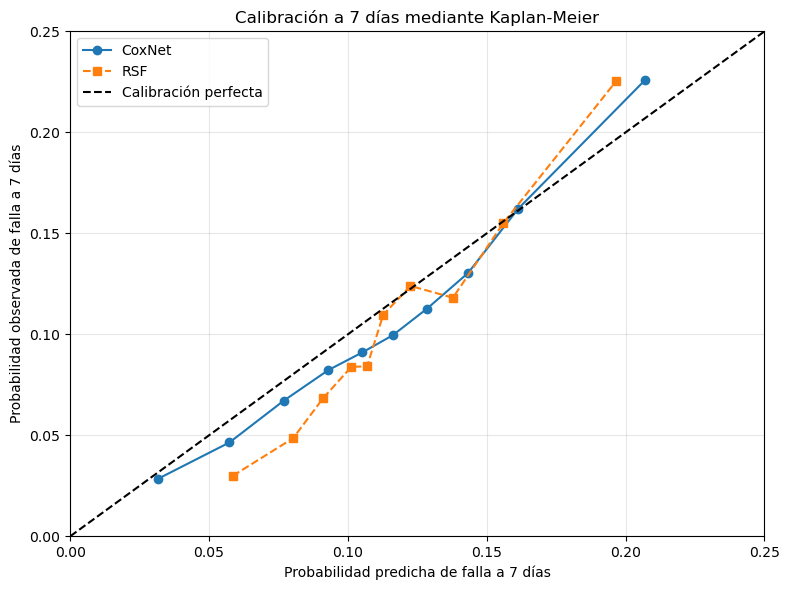

In [26]:
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# Función para estimar probabilidad observada de falla
# a 7 días mediante Kaplan-Meier
# =========================================================
def prob_falla_km_7d(eventos, tiempos, horizonte=7.0):
    t_km, s_km = kaplan_meier_estimator(
        eventos.astype(bool),
        tiempos.astype(float)
    )

    previos = s_km[t_km <= horizonte]

    if len(previos) == 0:
        supervivencia = 1.0
    else:
        supervivencia = previos[-1]

    return 1 - supervivencia


# =========================================================
# Función para construir tabla de calibración
# =========================================================
def calibracion_km(prob_pred, y, n_bins=10):

    # Asegurar probabilidades dentro del intervalo [0, 1]
    prob_pred = np.clip(
        prob_pred,
        0,
        1
    )

    base = pd.DataFrame({
        'prob': prob_pred,
        'event': y['event'],
        'time': y['time']
    })

    # Dividir las predicciones en deciles
    base['bin'] = pd.qcut(
        base['prob'],
        q=n_bins,
        duplicates='drop'
    )

    filas = []

    for _, g in base.groupby(
        'bin',
        observed=True
    ):

        filas.append({
            'prob_predicha': g['prob'].mean(),

            'prob_observada': prob_falla_km_7d(
                g['event'].to_numpy(),
                g['time'].to_numpy(),
                HORIZONTE_DIAS
            ),

            'n': len(g)
        })

    return pd.DataFrame(filas)


# =========================================================
# Calibración CoxNet y RSF
# =========================================================

# Probabilidad de falla = 1 - probabilidad de supervivencia
cal_cox = calibracion_km(
    1 - surv_prob_cox_7d,
    y_test
)

cal_rsf = calibracion_km(
    1 - surv_prob_rsf_7d,
    y_test
)


# =========================================================
# Mostrar tablas de calibración
# =========================================================
print("Calibración CoxNet")
display(
    cal_cox.round(4)
)

print("Calibración Random Survival Forest")
display(
    cal_rsf.round(4)
)


# =========================================================
# Gráfico de calibración
# =========================================================
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    cal_cox['prob_predicha'],
    cal_cox['prob_observada'],
    'o-',
    label='CoxNet'
)

plt.plot(
    cal_rsf['prob_predicha'],
    cal_rsf['prob_observada'],
    's--',
    label='RSF'
)

# Rango observado de probabilidades
limite = 0.25

# Línea ideal de calibración
plt.plot(
    [0, limite],
    [0, limite],
    'k--',
    label='Calibración perfecta'
)

# Zoom sobre el rango donde realmente están los datos
plt.xlim(
    0,
    limite
)

plt.ylim(
    0,
    limite
)

plt.xlabel(
    'Probabilidad predicha de falla a 7 días'
)

plt.ylabel(
    'Probabilidad observada de falla a 7 días'
)

plt.title(
    'Calibración a 7 días mediante Kaplan-Meier'
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Selección del modelo final

El modelo final se selecciona exclusivamente a partir del C-Index obtenido en el conjunto de validación de mayo. El conjunto de junio se utiliza como prueba final independiente para evaluar su capacidad de generalización. El Brier Score, el IBS y la calibración se emplean como métricas complementarias para valorar la precisión de las probabilidades estimadas.


In [28]:

# Selección del modelo final a partir del conjunto de validación


if cindex_rsf_val > best_cindex_cox_val:
    modelo_seleccionado = 'RSF'
else:
    modelo_seleccionado = 'CoxNet'

print(f"Modelo seleccionado según validación: {modelo_seleccionado}")

Modelo seleccionado según validación: CoxNet


In [29]:
print(
    f"C-Index final en junio -> "
    f"CoxNet: {cindex_cox:.4f} | "
    f"RSF: {cindex_rsf:.4f}"
)

C-Index final en junio -> CoxNet: 0.6520 | RSF: 0.6468


## Auditoría de estabilidad por cliente

El cliente no participa en el modelo principal, pero se mantiene para comprobar si el desempeño agregado está dominado por uno o pocos operadores. Se calcula el C-Index por cliente cuando existe un número mínimo de observaciones y eventos.


In [30]:

# Auditoría de estabilidad del modelo por cliente


# Utilizar las predicciones del modelo seleccionado previamente
riesgo_principal = (
    riesgo_rsf
    if modelo_seleccionado == 'RSF'
    else riesgo_cox
)

# Cliente se utiliza únicamente para auditoría,
# no como variable del modelo principal
eval_cliente = df_test[
    ['clientebd', 'event', 'duration']
].copy()

eval_cliente['riesgo'] = riesgo_principal

metricas_cliente = []
clientes_omitidos = 0

for cliente, g in eval_cliente.groupby(
    'clientebd',
    dropna=False
):
    eventos = int(g['event'].sum())

    # Evitar C-Index poco estable en grupos demasiado pequeños
    if len(g) < 30 or eventos < 5:
        clientes_omitidos += 1
        continue

    ci = concordance_index_censored(
        g['event'].astype(bool).to_numpy(),
        g['duration'].astype(float).to_numpy(),
        g['riesgo'].to_numpy()
    )[0]

    if np.isfinite(ci):
        metricas_cliente.append({
            'clientebd': cliente,
            'registros_test': len(g),
            'eventos': eventos,
            'C-Index_cliente': ci
        })


metricas_cliente = pd.DataFrame(
    metricas_cliente
)

# C-Index global del modelo seleccionado
cindex_global = (
    cindex_rsf
    if modelo_seleccionado == 'RSF'
    else cindex_cox
)


if not metricas_cliente.empty:

    metricas_cliente = (
        metricas_cliente
        .sort_values(
            'registros_test',
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Promedio simple para que cada cliente tenga el mismo peso
    cindex_macro_clientes = (
        metricas_cliente[
            'C-Index_cliente'
        ].mean()
    )

    print(
        f"Modelo auditado: "
        f"{modelo_seleccionado}"
    )

    print(
        f"C-Index global: "
        f"{cindex_global:.4f}"
    )

    print(
        f"C-Index promedio simple entre clientes: "
        f"{cindex_macro_clientes:.4f}"
    )

    print(
        f"Clientes evaluados: "
        f"{len(metricas_cliente)}"
    )

    print(
        f"Clientes omitidos por baja muestra/eventos: "
        f"{clientes_omitidos}"
    )

    display(
        metricas_cliente.round(4)
    )

else:

    cindex_macro_clientes = np.nan

    print(
        "No hay suficientes observaciones "
        "por cliente para obtener métricas estables."
    )

Modelo auditado: CoxNet
C-Index global: 0.6520
C-Index promedio simple entre clientes: 0.6033
Clientes evaluados: 52
Clientes omitidos por baja muestra/eventos: 1


,clientebd,registros_test,eventos,C-Index_cliente
0,COC12,2534,522,0.6271
1,COC01,1971,340,0.6898
2,COJ01,1606,396,0.6130
3,COM05,1529,285,0.5770
4,COS02,1508,293,0.6223
5,COH03,1340,351,0.6400
6,COI01,1298,277,0.5898
7,COS01,1145,162,0.5913
8,COA02,1084,80,0.5859
9,COC11,1042,241,0.5963


## Prueba de sensibilidad de `clientebd`

Para comprobar si el cliente contiene una señal adicional, se realiza una prueba complementaria con CoxNet incluyendo `clientebd`. Esta prueba no modifica automáticamente el modelo principal; sirve para cuantificar si existen diferencias operacionales asociadas al cliente que no están recogidas por otras variables.


In [31]:
# Prueba de sensibilidad: inclusión de clientebd

# Esta variante se utiliza únicamente como análisis de sensibilidad.
# El modelo principal mantiene clientebd fuera de las variables predictoras.

cat_cols_cliente = cat_cols + ['clientebd']
feature_cols_cliente = cat_cols_cliente + num_cols

preprocessor_cliente = crear_preprocesador_cox(
    cat_cols_cliente
)

X_train_cliente = preprocessor_cliente.fit_transform(
    df_train[feature_cols_cliente]
).astype(np.float32)

X_val_cliente = preprocessor_cliente.transform(
    df_val[feature_cols_cliente]
).astype(np.float32)

cox_cliente_path = CoxnetSurvivalAnalysis(
    l1_ratio=best_l1_ratio,
    n_alphas=30,
    alpha_min_ratio=0.01,
    fit_baseline_model=True
)

cox_cliente_path.fit(
    X_train_cliente,
    y_train
)

resultados_cliente = []

for alpha in cox_cliente_path.alphas_:

    riesgo_cliente = cox_cliente_path.predict(
        X_val_cliente,
        alpha=alpha
    )

    ci = concordance_index_censored(
        y_val['event'],
        y_val['time'],
        riesgo_cliente
    )[0]

    resultados_cliente.append(
        (alpha, ci)
    )


best_alpha_cliente, cindex_cliente_val = max(
    resultados_cliente,
    key=lambda x: x[1]
)

delta_cliente = (
    cindex_cliente_val -
    best_cindex_cox_val
)

comparacion_cliente = pd.DataFrame({
    'Configuración CoxNet': [
        'Sin clientebd',
        'Con clientebd'
    ],
    'C-Index validación': [
        best_cindex_cox_val,
        cindex_cliente_val
    ]
})

display(
    comparacion_cliente.round(4)
)

print(
    f"Mejor alpha con clientebd: "
    f"{best_alpha_cliente:.6f}"
)

print(
    f"Cambio de C-Index al incluir clientebd: "
    f"{delta_cliente:+.4f}"
)

if abs(delta_cliente) < 0.01:
    print(
        "Interpretación: la inclusión de clientebd "
        "produce un cambio pequeño en el rendimiento."
    )
elif delta_cliente > 0:
    print(
        "Interpretación: clientebd aporta señal predictiva "
        "adicional, aunque debe interpretarse como variable "
        "de contexto y no como causa de falla."
    )
else:
    print(
        "Interpretación: incluir clientebd no mejora "
        "el rendimiento de validación."
    )

,Configuración CoxNet,C-Index validación
0,Sin clientebd,0.6501
1,Con clientebd,0.6645


Mejor alpha con clientebd: 0.001316
Cambio de C-Index al incluir clientebd: +0.0144
Interpretación: clientebd aporta señal predictiva adicional, aunque debe interpretarse como variable de contexto y no como causa de falla.


### Sensibilidad final de clientebd sobre el test de junio
### Se utiliza el alpha seleccionado previamente en validación
### para evitar ajustar nuevamente hiperparámetros con el test.

In [32]:
# Sensibilidad final de clientebd sobre el test de junio

# Se utiliza el alpha seleccionado previamente en validación
# para evitar ajustar nuevamente hiperparámetros con el test.

cat_cols_cliente_final = cat_cols + ['clientebd']
feature_cols_cliente_final = cat_cols_cliente_final + num_cols

preprocessor_cliente_final = crear_preprocesador_cox(
    cat_cols_cliente_final
)

X_train_cliente_final = (
    preprocessor_cliente_final
    .fit_transform(
        df_train_final[feature_cols_cliente_final]
    )
    .astype(np.float32)
)

X_test_cliente_final = (
    preprocessor_cliente_final
    .transform(
        df_test[feature_cols_cliente_final]
    )
    .astype(np.float32)
)

cox_cliente_final = CoxnetSurvivalAnalysis(
    l1_ratio=best_l1_ratio,
    alphas=[best_alpha_cliente],
    fit_baseline_model=True
)

cox_cliente_final.fit(
    X_train_cliente_final,
    y_train_final
)

riesgo_cliente_test = cox_cliente_final.predict(
    X_test_cliente_final
)

cindex_cliente_test = concordance_index_censored(
    y_test['event'],
    y_test['time'],
    riesgo_cliente_test
)[0]

delta_cliente_test = (
    cindex_cliente_test -
    cindex_cox
)

comparacion_cliente_test = pd.DataFrame({
    'Configuración CoxNet': [
        'Sin clientebd',
        'Con clientebd'
    ],
    'C-Index junio': [
        cindex_cox,
        cindex_cliente_test
    ]
})

display(
    comparacion_cliente_test.round(4)
)

print(
    f"Cambio de C-Index en junio al incluir clientebd: "
    f"{delta_cliente_test:+.4f}"
)

,Configuración CoxNet,C-Index junio
0,Sin clientebd,0.6520
1,Con clientebd,0.6684


Cambio de C-Index en junio al incluir clientebd: +0.0165


# Aplicación operacional del modelo seleccionado

Se construye una única fotografía por bus en la fecha final disponible. El ranking contiene un bus una sola vez y conserva `clientebd` únicamente para auditoría del resultado.


In [ ]:
# Aplicación operacional del modelo seleccionado

import joblib
from pathlib import Path


# 1. Reentrenamiento con todo el histórico disponible

df_deploy = construir_objetivo_panel(
    df_panel,
    fecha_fin + pd.Timedelta(microseconds=1)
)

y_deploy = crear_y(df_deploy)

fecha_corte_operativa = fecha_fin

# Un único snapshot actual por bus
snapshot_flota = construir_snapshot_semanal(
    df_hist,
    fecha_corte_operativa
)


# 2. Preparación de variables

for col in cat_cols + ['clientebd']:
    snapshot_flota[col] = (
        snapshot_flota[col]
        .fillna('DESCONOCIDO')
        .astype(str)
    )

for col in num_cols:
    snapshot_flota[col] = (
        pd.to_numeric(
            snapshot_flota[col],
            errors='coerce'
        )
        .fillna(0)
    )


# 3. Entrenamiento del modelo definitivo

if modelo_seleccionado == 'RSF':

    preprocessor_deploy = crear_preprocesador_rsf(
        rsf_cat_cols
    )

    X_deploy = preprocessor_deploy.fit_transform(
        df_deploy[rsf_feature_cols]
    ).astype(np.float32)

    X_snapshot = preprocessor_deploy.transform(
        snapshot_flota[rsf_feature_cols]
    ).astype(np.float32)

    modelo_deploy = RandomSurvivalForest(
        n_estimators=40,
        max_depth=4,
        min_samples_split=30,
        min_samples_leaf=40,
        max_features='sqrt',
        max_samples=0.35,
        random_state=42,
        n_jobs=1
    )

else:

    preprocessor_deploy = crear_preprocesador_cox(
        cat_cols
    )

    X_deploy = preprocessor_deploy.fit_transform(
        df_deploy[feature_cols]
    ).astype(np.float32)

    X_snapshot = preprocessor_deploy.transform(
        snapshot_flota[feature_cols]
    ).astype(np.float32)

    modelo_deploy = CoxnetSurvivalAnalysis(
        l1_ratio=best_l1_ratio,
        alphas=[best_alpha],
        fit_baseline_model=True
    )


modelo_deploy.fit(
    X_deploy,
    y_deploy
)

print(
    f"Modelo de despliegue entrenado: "
    f"{modelo_seleccionado}"
)

# 4. Probabilidad estimada de falla a 7 días por lotes

def probabilidad_falla_por_lotes(
    modelo,
    X,
    horizonte,
    batch_size=25
):
    probabilidades = np.empty(
        X.shape[0],
        dtype=np.float64
    )

    total = X.shape[0]

    for inicio in range(0, total, batch_size):
        fin = min(
            inicio + batch_size,
            total
        )

        funciones_lote = (
            modelo.predict_survival_function(
                X[inicio:fin]
            )
        )

        probabilidades[inicio:fin] = [
            1 - fn(horizonte)
            for fn in funciones_lote
        ]

        if fin % 1000 == 0 or fin == total:
            print(
                f"Predicción operacional: "
                f"{fin:,} / {total:,}"
            )

        del funciones_lote
        gc.collect()

    return np.clip(
        probabilidades,
        0,
        1
    )


snapshot_flota['Prob_Falla_7_Dias'] = (
    probabilidad_falla_por_lotes(
        modelo=modelo_deploy,
        X=X_snapshot,
        horizonte=HORIZONTE_DIAS,
        batch_size=25
    )
)


# 5. Ranking completo de la flota

columnas_salida = [
    'id_movil',
    'clientebd',
    'Prob_Falla_7_Dias'
]

# Agregar variables explicativas si están disponibles
columnas_contexto = [
    'dias_desde_ultima_atribuible',
    'fallas_atribuibles_7d',
    'fallas_atribuibles_30d',
    'no_falla_7d',
    'no_falla_30d',
    'mtto_preventivo_7d',
    'mtto_preventivo_30d'
]

for col in columnas_contexto:
    if col in snapshot_flota.columns:
        columnas_salida.append(col)


ranking_flota = (
    snapshot_flota[columnas_salida]
    .sort_values(
        'Prob_Falla_7_Dias',
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_flota.insert(
    0,
    'Posicion',
    np.arange(
        1,
        len(ranking_flota) + 1
    )
)


# 6. Top buses con mayor riesgo

TOP_N = 10

top_riesgo = (
    ranking_flota
    .head(TOP_N)
    .copy()
)

print(
    f"\nTOP {TOP_N} buses con mayor "
    f"probabilidad estimada de falla a 7 días"
)

display(
    top_riesgo.round(4)
)

# 7. Control de concentración por cliente

concentracion_top = (
    top_riesgo['clientebd']
    .value_counts(normalize=True)
)

if not concentracion_top.empty:
    print(
        f"Mayor participación de un cliente "
        f"dentro del TOP {TOP_N}: "
        f"{concentracion_top.iloc[0]:.1%}"
    )


# 8. Guardar modelo y preprocesador

RUTA_SALIDA = Path(
    r"C:\TFM_Predictivo\salida"
)

RUTA_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    modelo_deploy,
    RUTA_SALIDA / "modelo_mantenimiento_predictivo.joblib"
)

joblib.dump(
    preprocessor_deploy,
    RUTA_SALIDA / "preprocesador_mantenimiento_predictivo.joblib"
)

print(
    "\nModelo y preprocesador guardados correctamente."
)

Modelo de despliegue entrenado: CoxNet

TOP 10 buses con mayor probabilidad estimada de falla a 7 días


,Posicion,id_movil,clientebd,Prob_Falla_7_Dias,dias_desde_ultima_atribuible,fallas_atribuibles_7d,fallas_atribuibles_30d,no_falla_7d,no_falla_30d,mtto_preventivo_7d,mtto_preventivo_30d
0,1,937100,COL01,0.4062,2.2332,1,11,2,11,0,0
1,2,704460,COI04,0.3997,0.1957,4,10,2,3,0,0
2,3,404133,COH03,0.3861,1.7964,1,13,1,4,0,1
3,4,937050,COL01,0.3594,4.1731,3,6,3,7,0,0
4,5,504421,COJ01,0.3532,5.4693,2,7,2,9,0,0
5,6,104425,COC09,0.3489,0.1931,5,7,4,4,0,0
6,7,704979,COI02,0.3424,1.5778,1,3,3,5,0,0
7,8,507045,COJ01,0.3356,2.9219,1,9,1,6,0,0
8,9,707414,COI06,0.3281,7.6656,0,9,1,13,0,1
9,10,407233,COH03,0.3276,1.9100,3,7,1,11,0,1


Mayor participación de un cliente dentro del TOP 10: 20.0%

Modelo y preprocesador guardados correctamente.


### Curvas de supervivencia de los buses con mayor riesgo


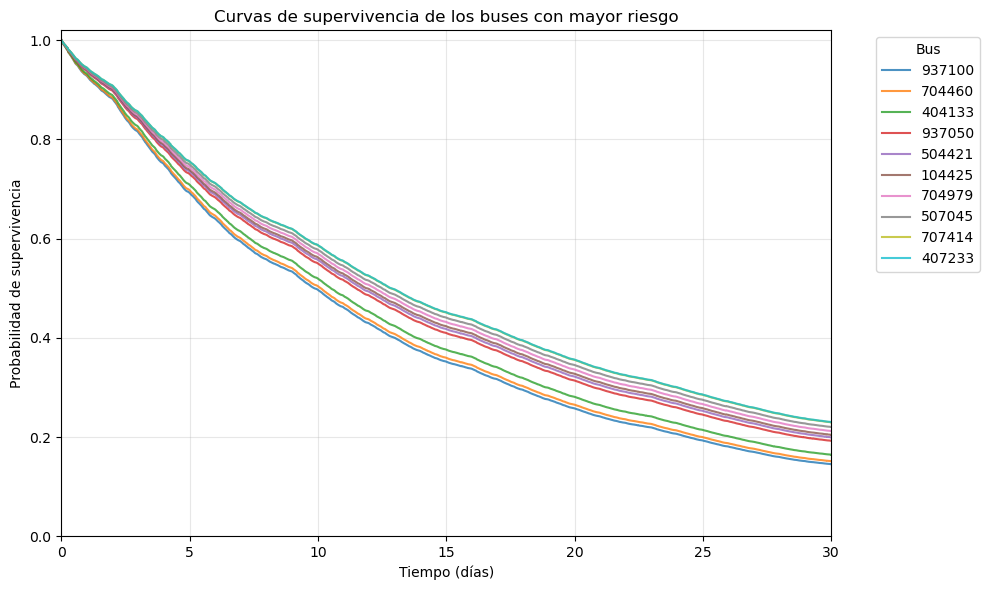

In [ ]:

# Curvas de supervivencia únicamente para el Top 10

snapshot_pos = (
    snapshot_flota
    .reset_index(drop=True)
)

posiciones = [
    snapshot_pos.index[
        snapshot_pos['id_movil'] == bus
    ][0]
    for bus in top_riesgo['id_movil']
]

X_top_riesgo = X_snapshot[
    np.asarray(
        posiciones,
        dtype=int
    )
]

# Solo se calculan las curvas completas de los diez buses
surv_top_riesgo = (
    modelo_deploy.predict_survival_function(
        X_top_riesgo
    )
)

plt.figure(
    figsize=(10, 6)
)

for bus, fn in zip(
    top_riesgo['id_movil'],
    surv_top_riesgo
):
    plt.step(
        fn.x,
        fn.y,
        where='post',
        alpha=0.8,
        label=str(bus)
    )

max_tiempo = max(
    float(fn.x[-1])
    for fn in surv_top_riesgo
)

plt.xlim(
    0,
    min(30, max_tiempo)
)

plt.ylim(
    0,
    1.02
)

plt.xlabel(
    'Tiempo (días)'
)

plt.ylabel(
    'Probabilidad de supervivencia'
)

plt.title(
    'Curvas de supervivencia de los buses con mayor riesgo'
)

plt.legend(
    title='Bus',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()
